# 1 · The immutable evaluator & your first baseline

This is the heart of the whole book: a **scoring function the agent can never
touch**. Everything the harness does is judged by it.

We:
1. load the BDD-style dataset (synthetic, but same schema/attributes as BDD100K),
2. train a quick baseline CNN,
3. score it with `harness.evaluator` — and discover the **worst slice**.

The score is `worst_group_accuracy + 0.25 * macro_accuracy`, where groups are
the `weather` slices. We optimize the *worst* slice on purpose: a perception
model that is blind in fog is not safe, no matter how good its average is.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # make `harness` importable
import matplotlib
matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    print("building a small bdd-tiny ...")
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA)

dataset: ../data/bdd-tiny.lance


### A look at the data — driving frames tagged with weather / timeofday

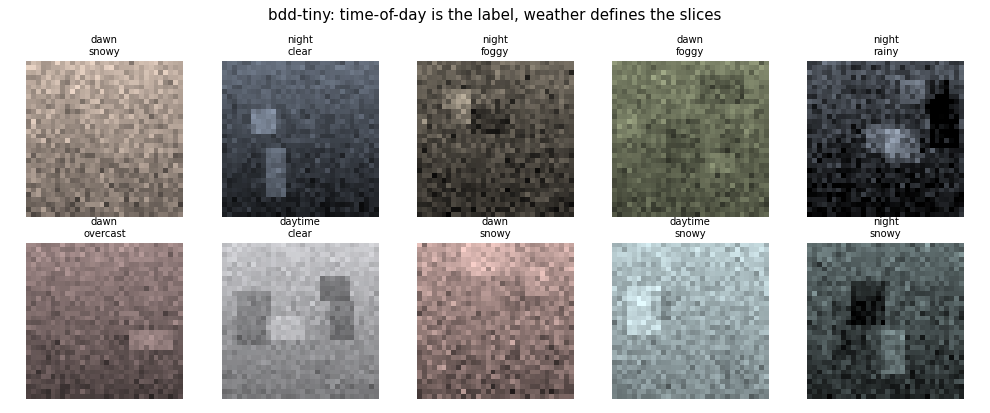

In [2]:
x, y, meta = load_split(DATA, "train")
names = class_names()
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for ax, i in zip(axes.ravel(), np.random.default_rng(0).choice(len(x), 10, replace=False)):
    ax.imshow(np.clip(x[i], 0, 1)); ax.axis("off")
    ax.set_title(f"{names[y[i]]}\n{meta['weather'][i]}", fontsize=8)
fig.suptitle("bdd-tiny: time-of-day is the label, weather defines the slices")
fig.tight_layout(); fig.savefig("fig_01_frames.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_01_frames.png")

### Train a quick baseline under the compute budget

In [3]:
from harness.config import load_config
from harness.train import train

cfg = load_config("base", {"budget": {"max_epochs": 12, "max_seconds": 60}})
model = train(cfg, DATA)
print("validation accuracy:", model.metrics["val_acc"],
      "| epochs:", model.metrics["epochs_run"],
      "| seconds:", model.metrics["seconds"])

validation accuracy: 0.9733 | epochs: 12 | seconds: 3.89


### Score it with the immutable evaluator

In [4]:
from harness.evaluator import evaluate
res = evaluate(model, DATA)
print("OFFICIAL SCORE :", res["score"])
print("worst slice    :", res["worst_group_name"], "=", res["worst_group"])
print("overall acc    :", res["overall_accuracy"])
print("macro acc      :", res["macro_accuracy"])
res["per_weather"]

OFFICIAL SCORE : 0.8835
worst slice    : foggy = 0.6444
overall acc    : 0.9556
macro acc      : 0.9562


{'clear': 1.0,
 'foggy': 0.6444,
 'overcast': 1.0,
 'rainy': 0.9639,
 'snowy': 0.9863}

### The worst slice, visualized

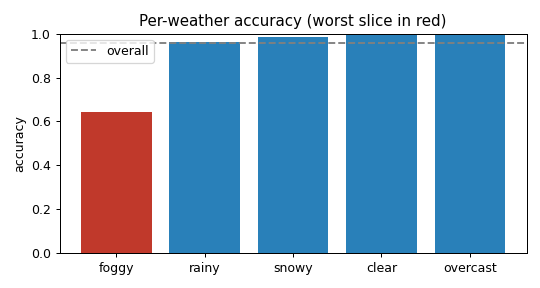

In [5]:
pw = res["per_weather"]
order = sorted(pw, key=pw.get)
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(order, [pw[w] for w in order],
              color=["#c0392b" if w == res["worst_group_name"] else "#2980b9" for w in order])
ax.set_ylim(0, 1); ax.set_ylabel("accuracy"); ax.set_title("Per-weather accuracy (worst slice in red)")
ax.axhline(res["overall_accuracy"], ls="--", c="gray", label="overall")
ax.legend(); fig.tight_layout(); fig.savefig("fig_01_slices.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_01_slices.png")

**Read the result.** The baseline is strong on the common, well-lit weather but
weakest on **fog** — fog is rare in the data and its cues are washed out. The
whole job of the harness, in the chapters that follow, is to raise that worst
slice *without ever editing this evaluator*.